In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("Stress_Distribution_notebook.ipynb")

ModuleNotFoundError: No module named 'otter'

# Geotechnical and Geoenvironmental Engineering: Stress Distribution

> **Alex Frantzis** <br> Cool Student >:3, UC Berkeley

[![License](https://img.shields.io/badge/license-CC%20BY--NC--ND%204.0-blue)](https://creativecommons.org/licenses/by-nc-nd/4.0/)
***

In [2]:
# Please run this cell, and do not modify the contents

import hashlib
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()
    
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Vertical Stress Distribution in Soil

## Introduction

In geotechnical engineering, understanding how stresses from surface loads travel through soil is essential for evaluating settlement, bearing capacity, and the potential for soil failure. Because soil is a complex, nonlinear, and often heterogeneous material, engineers rely on several analytical methods, each with its own assumptions to estimate how vertical stress spreads with depth.

In this assignment, you will implement **two classical stress distribution methods** in code:

1. **2:1 Method (Approximate/Empirical)**
2. **Boussinesq Method (Elastic Half Space Theory)**

You will apply each method to the same loading scenario and soil profile, compute stress at various depths, and compare the outputs and behavior of each method. By the end, you should understand **how and why different methods give different stress predictions**, and which method is most appropriate in different engineering contexts.


## Question 1: 2:1 Method

The **2:1 method** is a simple approximate technique often used for quick estimates.

It assumes that the vertical stress spreads out in a **pyramid shape**, with the loaded area expanding at a slope of **2 vertical : 1 horizontal**.

- Stress diminishes with depth as the load spreads over a larger area.
- It ignores soil stiffness, layering, and elasticity.
- Best used as a **fast check** or when limited data is available.

---
### The loaded area expands linearly with depth:

$$
B_{z} = B + z    
$$
$$
L_{z} = L + z
$$

### Area at depth z
$$
A(z) = B_z * L_z
$$
### Vertical stress at depth z

Assuming the entire load Q spreads uniformly over A(z):
$$
\sigma_{z}(z) = Q / A(z)
$$
### Units:
- Q in kN  
- A(z) in m²  
- sigma_z in kPa (because kN/m² = kPa)
<center><img src="resources/2to1Diagram.png" width='650'/></center>
---
Image from Holtz, Kovacs, and Sheahan

Write a function named `stress_2to1()` that calculates the stress at specified depth using the 2:1 method. This function has the following input argument:
* `load`, which is the applied load normal to the surface. (kPa)
* `width`, which is the width of the surface where the load is applied. (m)
* `length`, which is the length of the surface where the load is applied. (m)
* `depth`, which is the depth below the surface where the stress is to be found. (m)

and the following output arguments.
* `stress`, vertical stress at depth z (kPa)
---
We are assuming that the stress is taken within the range in which 2:1 is valid

In [3]:
import numpy as np

def stress_2to1(load, width, length, depth):
    Bz = width + depth # SOLUTION
    Lz = length + depth # SOLUTION

    # Area at depth z
    Az = Bz * Lz

    # Stress = load / area
    sigma_z = load / Az

    return sigma_z


In [4]:
# TEST YOUR FUNCTION HERE
depth = 3 # SOLUTION
q1 = stress_2to1(1200, 3,4, depth) # SOLUTION

# print result
print(f'Stress at depth {depth} = {q1}')

Stress at depth 3 = 28.571428571428573


In [5]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to test your function!
""" # END TEST CONFIG

# Check students tested the function (type is not ellipsis)
assert get_hash(type(q1)) != '14e736438b115821cbb9b7ac0ba79034'

In [6]:
""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion is getting some calculations wrong!
success_message: Function correctly classifies all scalar test cases :D
""" # END TEST CONFIG

assert get_hash(np.round(stress_2to1(1200,3,4,0))) == '62dca49f0781bf26b4305bddb0414bea'
assert get_hash(np.round(stress_2to1(1200,3,4,2))) == '40e5fa722621b4033c15162806b7ea2b'
assert get_hash(np.round(stress_2to1(1200,3,4,5))) == '8011c1672b96b9446e250a64eb52393f'
assert get_hash(np.round(stress_2to1(1200,3,4,20))) == 'd1bd83a33f1a841ab7fda32449746cc4'

In [7]:
""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion is getting some calculations wrong!
success_message: Function correctly classifies all scalar test cases :D
""" # END TEST CONFIG

assert get_hash(np.round(stress_2to1(2000,10,10,0))) == '75cf3ac5e70c76583be3efb5012bd44e'
assert get_hash(np.round(stress_2to1(2000,10,10,2))) == '038a8a50b863780fe4a43b7a263bb12b'
assert get_hash(np.round(stress_2to1(2000,10,10,5))) == 'cf5f238fca8b6e155078aa41c175743a'
assert get_hash(np.round(stress_2to1(2000,10,10,20))) == 'd1bd83a33f1a841ab7fda32449746cc4'

## Question 2: Boussinesq Method

The **Boussinesq solution** comes from elasticity theory for a *homogeneous, isotropic, elastic half-space*.  
It gives an exact theoretical solution for stress beneath a point load or a uniformly loaded area.

### Key ideas:
- Stress decays with depth based on the geometry and elastic behavior.  
- Typically gives **higher stresses** than the 2:1 method at shallow depths.  
- More accurate when the soil behaves close to elastic and uniform.


---
If one was made to hand ca
## Boussinesq Point Load Equation

For a point load dQ located a horizontal distance r away from the point where stress is evaluated:

Vertical stress contribution from that element:
$$
    dσ_z = (3 * dQ / (2π)) * (z^3 / (r^2 + z^2)^{(5/2)})
$$
Where:
- z = depth  
- r = sqrt(x² + y²), the radial distance from element dA  
- dQ = q * dA  
- q = Q / (B * L), (for uniform pressure)  

---

## Numerical Integration Concept

1. **Divide the footing area into a grid:**

       x ∈ [−B/2, B/2],      y ∈ [−L/2, L/2]

2. **Compute the area of each small element:**

       dA = dx * dy

3. **For each element:**
   - Compute the distance r  
   - Compute point stress dσz from the formula above  
   - Add it to the cumulative total

4. **The numerical sum approximates the exact vertical stress.**


---
Write a function named `stress_boussinesq()` that calculates the stress at specified depth using the boussinesq method. This function has the following input argument:
* `load`, which is the applied load normal to the surface. (kPa)
* `width`, which is the width of the surface where the load is applied. (m)
* `length`, which is the length of the surface where the load is applied. (m)
* `depth`, which is the depth below the surface where the stress is to be found. (m)
* `nx`, which is the number of grid samples to take in the x direction.
* `nx`, which is the number of grid samples to take in the y direction.
* `xpos`, which is the position where stress is measured in the x direction.
* `ypos`, which is the position where stress is measured in the y direction.

and the following output arguments.
* `stress`, vertical stress at depth z (kPa)
---
We have assumed a square shaped load to simplify the procedure, but the process and concept is extendable to any arbitrary shape and stress distribution.

In [8]:
import numpy as np

def stress_boussinesq(load, width, length, depth, nx=400, ny=400, xpos = 0, ypos = 0):
    # Uniform pressure q (kPa)
    q = load / (width * length) # SOLUTION

    # Discretize the area
    x = np.linspace(-width/2, width/2, nx)
    y = np.linspace(-length/2, length/2, ny) # SOLUTION
    dx = x[1] - x[0] # SOLUTION
    dy = y[1] - y[0] # SOLUTION

    X, Y = np.meshgrid(x, y)

    # Distance r from each element to the point below the center
    r = np.sqrt((X- xpos)**2 + (Y- ypos)**2)

    # Boussinesq point stress
    dA = dx * dy # SOLUTION
    dQ = q * dA # SOLUTION

    dSigma = (3 * dQ / (2 * np.pi)) * (depth**3) / (r**2 + depth**2)**(5/2) # SOLUTION

    stress = np.sum(dSigma)

    return stress


In [9]:
# TEST YOUR FUNCTION HERE
depth = 20# SOLUTION
q2 = stress_boussinesq(20000,10,10,depth, 600, 600, 5, 5) # SOLUTION

# print result
print(f'Stress at depth {depth} = {q2}')

Stress at depth 20 = 16.858356185578014


In [10]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to test your function!
""" # END TEST CONFIG

# Check students tested the function (type is not ellipsis)
assert get_hash(type(q2)) != '14e736438b115821cbb9b7ac0ba79034'

In [11]:
""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion is getting some calculations wrong!
success_message: Function correctly classifies all scalar test cases :D
""" # END TEST CONFIG

assert get_hash(int(stress_boussinesq(1200,3,4,0, 400, 400))) == 'cfcd208495d565ef66e7dff9f98764da'
assert get_hash(int(stress_boussinesq(1200,3,4,2, 400, 400))) == '44f683a84163b3523afe57c2e008bc8c'
assert get_hash(int(stress_boussinesq(1200,3,4,5, 400, 400))) == '1f0e3dad99908345f7439f8ffabdffc4'
assert get_hash(int(stress_boussinesq(1200,3,4,20, 400, 400)))  == 'c4ca4238a0b923820dcc509a6f75849b'

In [12]:
""" # BEGIN TEST CONFIG
name: Starting Calcs
points: 0
failure_message: Your funtion is getting some calculations wrong!
success_message: Function correctly classifies all scalar test cases :D
""" # END TEST CONFIG

assert get_hash(int(stress_boussinesq(20000,10,10,2, 600, 600, 5, 5))) =='c0c7c76d30bd3dcaefc96f40275bdc0a'
assert get_hash(int(stress_boussinesq(20000,10,10,4.85,600, 600, 5, 5))) =='d9d4f495e875a2e075a1a4a6e1b9770f'
assert get_hash(int(stress_boussinesq(20000,10,10,20,600, 600, 5, 5))) == 'c74d97b01eae257e44aa9d5bade97baf'

## Question 3: Comparison of Vertical Stress Beneath a Square Footing

In this section, you will compare the vertical stress beneath the center of a square footing
using:

- **2:1 Load Distribution Method**
- **Boussinesq Elastic Solution**

The footing size is increased progressively while keeping:
- Total load constant
- Evaluation depth constant

You will plot the resulting stresses as a function of footing width to highlight
the differences between the two methods and observe their limiting behavior.

---

### Instructions

1. Use the previously defined functions:
   - `stress_2to1()`
   - `stress_boussinesq()`

2. Define square side lengths

3. Compute:
   - 2to1_stress (Stress at depth of 10m below the center of the square footing using 2to1 method)
   - bossinesque_stress (Stress at depth of 10m below the center of the square footing using bossinesque method)


   for the range of side lengths (0m to 50m size square footing).

4. Plot **2to1_stress** and **bossinesque_stress** on the same graph.

---

### Example Plot Layout
<center><img src="resources/example_Graph.png" width='650'/></center>

- **x-axis:** footing side length (m) — increasing **rightward**
- **y-axis:** stress kPa

Use different line styles or colors to distinguish:<br>
— Total Stress  
— Pore Water Pressure  
— Effective Stress  

Make sure to include:
- A **legend** identifying each curve  
- **Axis labels** with units  
--- 
### The parameters are the following 
```PYTHON
load =  1000 (kPa)
depth = 10 (m)
side lengths: range from 0 to 50 (spacing of 1 between each sample)
```



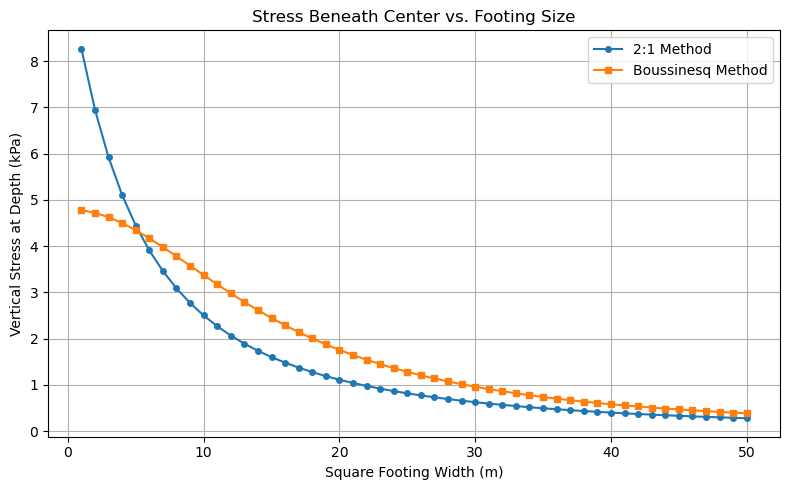

In [13]:
# Don't change function name. It must be "createFigure1" for testing purposes. Make sure the function returns the figure.
def createFigure1():
    # --- Parameters ---
    load = 1000        # SOLTION
    depth = 10        # SOLTION
    side_lengths = np.linspace(1, 50, 50)  # side lengths of square footing

    stresses_2to1 = []
    stresses_boussinesque = []

    # --- Compute stresses ---
    for len in side_lengths:
        # append stresses to list
        stresses_2to1.append(stress_2to1(load, len, len, depth)) # SOLTION
        stresses_boussinesque.append(stress_boussinesq(load, len, len, depth)) # SOLUTION

    # --- Plot ---
    fig_1 = plt.figure(figsize=(8, 5))
    plt.plot(side_lengths, stresses_2to1, 'o-', label='2:1 Method', markersize = 4) # SOLUTION
    plt.plot(side_lengths, stresses_boussinesque, 's-', label='Boussinesq Method', markersize = 4) # SOLUTION

    plt.xlabel('Square Footing Width (m)') # SOLUTION
    plt.ylabel('Vertical Stress at Depth (kPa)') # SOLUTION
    plt.title('Stress Beneath Center vs. Footing Size') # SOLUTION
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return fig_1

fig_1 = createFigure1()

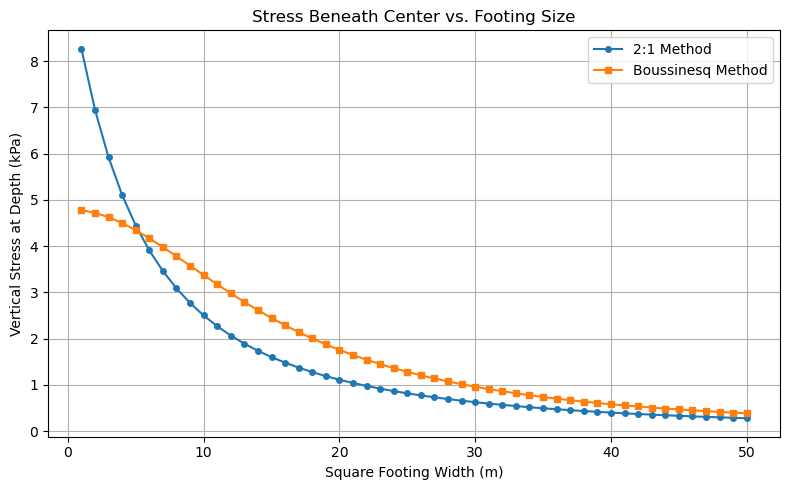

In [14]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Check x and y data of line plot 1.
""" # END TEST CONFIG
fig_1 = createFigure1()
# Check x data
assert get_hash(np.round(np.sum(fig_1.axes[0].get_lines()[0].get_xdata()),decimals=0)) == 'de24d118fbdc1df38f83572b5140dba2'
# Check y data
assert get_hash(np.round(np.sum(fig_1.axes[0].get_lines()[0].get_ydata()),decimals=0)) == 'a0daef9095a866b7c3652a1bc0d2fe8d'

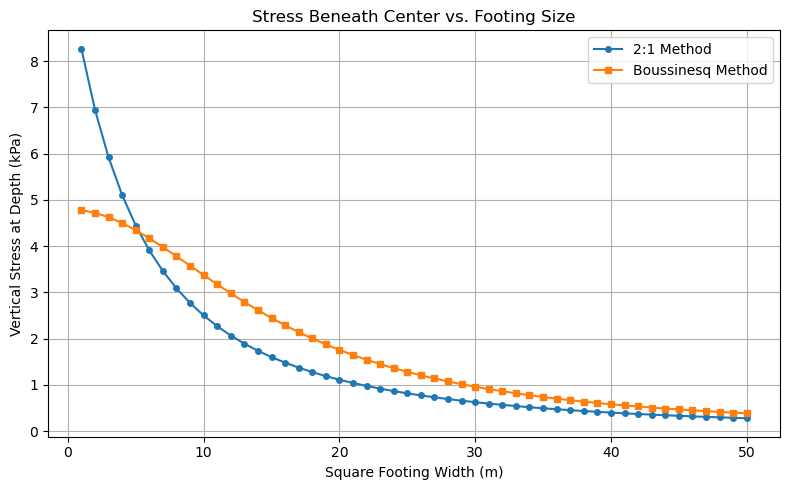

In [15]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Check x and y data of line plot 1.
""" # END TEST CONFIG
fig_1 = createFigure1()
# Check x data
assert get_hash(np.round(np.sum(fig_1.axes[0].get_lines()[1].get_xdata()),decimals=0)) == 'de24d118fbdc1df38f83572b5140dba2'
# Check y data
assert get_hash(np.round(np.sum(fig_1.axes[0].get_lines()[1].get_ydata()),decimals=0)) == 'e9eda2950317b1a7207dad4d91c03d87'

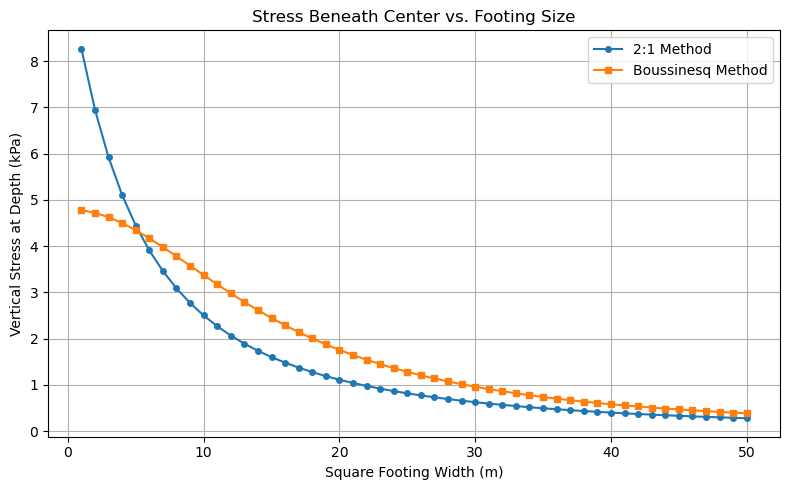

In [16]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Check figure labels and font sizes.
""" # END TEST CONFIG
fig_1 = createFigure1()
# Check xlabel and fontsize
x_string = ['SQUARE','WIDTH', 'M']
assert all([word in fig_1.axes[0].get_xlabel().upper() for word in x_string]), 'Check the x-axis label.'

# Check ylabel and fontsize
y_string = ['STRESS','KPA']
assert all([word in fig_1.axes[0].get_ylabel().upper() for word in y_string]), 'Check the y-axis label.'

## Further Comparison Example

For your viewing, here is a comparison of the two methods with a constant stress instead of constant load. The stress is 1000kPA and the total load increases proportionally to the increase in area as the square footing gets larger and larger. Do the graphs tell you anything about possible differences in the results produced by the methods?

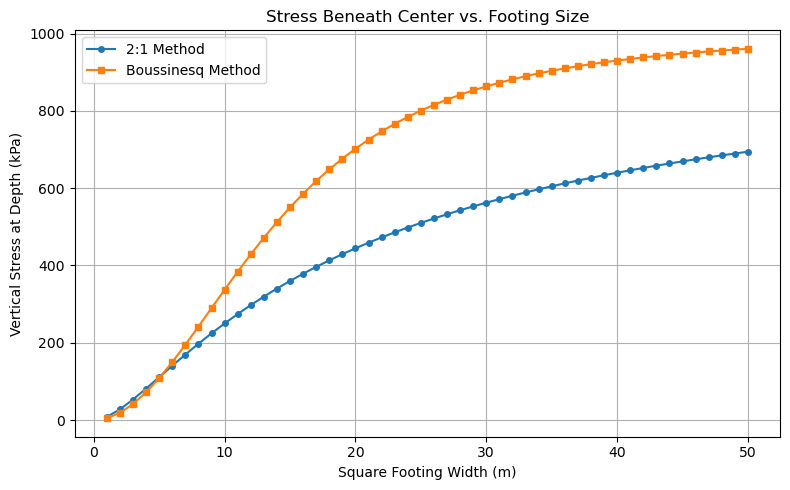

In [17]:
def createFigure2():
    # --- Parameters ---
    stress = 1000        # SOLTION
    depth = 10        # SOLTION
    side_lengths = np.linspace(1, 50, 50)  # side lengths of square footing

    stresses_2to1 = []
    stresses_boussinesque = []

    # --- Compute stresses ---
    for len in side_lengths:
        # append stresses to list
        stresses_2to1.append(stress_2to1(stress * (len * len), len, len, depth)) # SOLTION
        stresses_boussinesque.append(stress_boussinesq(stress * (len * len), len, len, depth)) # SOLUTION

    # --- Plot ---
    fig_1 = plt.figure(figsize=(8, 5))
    plt.plot(side_lengths, stresses_2to1, 'o-', label='2:1 Method', markersize = 4) # SOLUTION
    plt.plot(side_lengths, stresses_boussinesque, 's-', label='Boussinesq Method', markersize = 4) # SOLUTION

    plt.xlabel('Square Footing Width (m)') # SOLUTION
    plt.ylabel('Vertical Stress at Depth (kPa)') # SOLUTION
    plt.title('Stress Beneath Center vs. Footing Size') # SOLUTION
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    return fig_1

fig_2 = createFigure2()

## 2D Stress Distribution Heat Maps

To better visualize how stress distributes beneath a loaded footing, we can create **2D heat maps** showing stress variation with both **depth** (y-axis) and **horizontal position** (x-axis) across the middle of the footing.

### Key Observation: Horizontal Variability

The **2:1 method** calculates stress based solely on depth—it assumes uniform stress distribution across the entire expanded area at any given depth. This means:
- The stress value at depth z is the same whether you're directly beneath the center of the footing or near its edge
- The heat map will show **horizontal bands** of constant color at each depth

The **Boussinesq method**, in contrast, accounts for the **3D geometry** of stress distribution:
- Stress is highest directly beneath the loaded area and decreases as you move horizontally away from the center
- The heat map will show a **bulb-shaped** stress distribution, with stress concentrating beneath the footing and spreading out with depth

This difference is critical in practice—the 2:1 method can overestimate stress at locations away from the footing center and underestimate stress concentration directly beneath it.

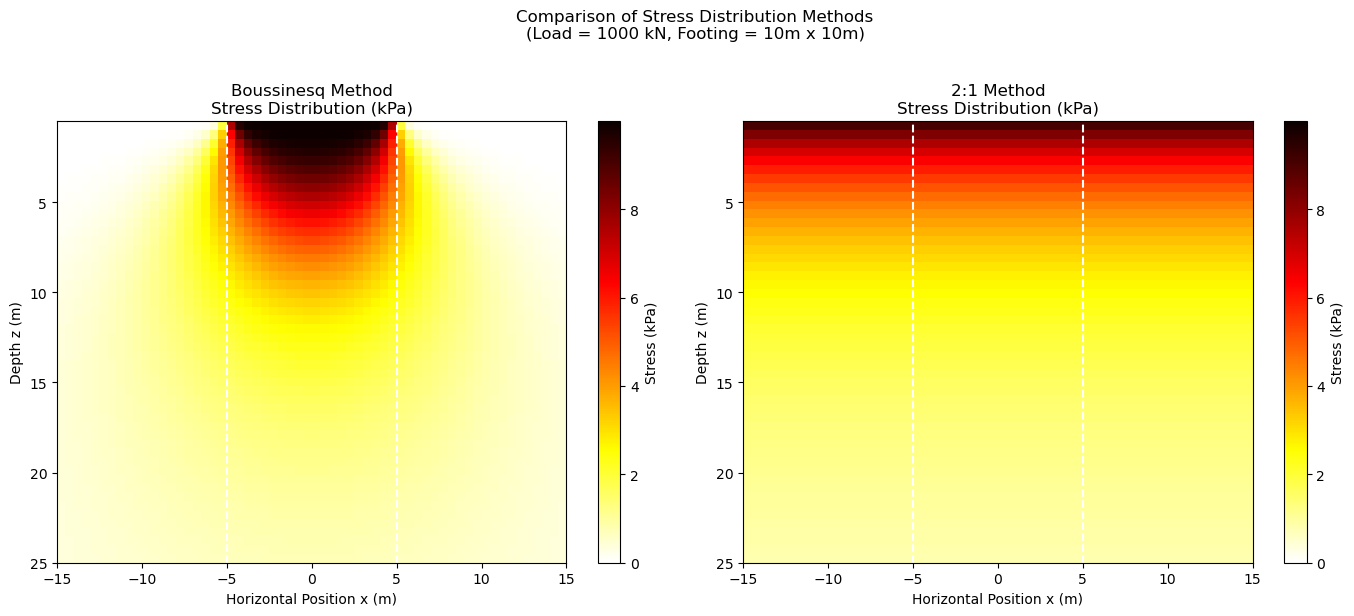

Notice how the Boussinesq method shows stress concentration beneath the footing
that decreases as you move horizontally away from the center.

The 2:1 method shows uniform horizontal bands - it does not capture
the variation in stress with horizontal position.


In [ ]:
# --- Parameters for heat map visualization ---
load = 1000          # Total load (kN)
width = 10           # Footing width (m)
length = 10          # Footing length (m)

# Define grid for heat map
x_positions = np.linspace(-15, 15, 60)   # Horizontal positions across the footing (m)
depths = np.linspace(0.5, 25, 50)        # Depths below surface (m)

# Initialize stress arrays
stress_boussinesq_2d = np.zeros((len(depths), len(x_positions)))
stress_2to1_2d = np.zeros((len(depths), len(x_positions)))

# Compute stress at each grid point
for i, z in enumerate(depths):
    for j, x in enumerate(x_positions):WS
        # Boussinesq method - varies with both depth AND horizontal position
        stress_boussinesq_2d[i, j] = stress_boussinesq(load, width, length, z, 
                                                        nx=100, ny=100, xpos=x, ypos=0)
        # 2:1 method - only depends on depth, NOT horizontal position
        stress_2to1_2d[i, j] = stress_2to1(load, width, length, z)

# --- Create side-by-side heat maps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Determine common color scale for comparison
vmin = 0
vmax = max(stress_boussinesq_2d.max(), stress_2to1_2d.max())

# Boussinesq Heat Map
im1 = axes[0].imshow(stress_boussinesq_2d, extent=[x_positions[0], x_positions[-1], depths[-1], depths[0]],
                      aspect='auto', cmap='hot_r', vmin=vmin, vmax=vmax)
axes[0].set_xlabel('Horizontal Position x (m)')
axes[0].set_ylabel('Depth z (m)')
axes[0].set_title('Boussinesq Method\nStress Distribution (kPa)')
axes[0].axvline(x=-width/2, color='white', linestyle='--', linewidth=1.5, label='Footing edge')
axes[0].axvline(x=width/2, color='white', linestyle='--', linewidth=1.5)
plt.colorbar(im1, ax=axes[0], label='Stress (kPa)')

# 2:1 Method Heat Map
im2 = axes[1].imshow(stress_2to1_2d, extent=[x_positions[0], x_positions[-1], depths[-1], depths[0]],
                      aspect='auto', cmap='hot_r', vmin=vmin, vmax=vmax)
axes[1].set_xlabel('Horizontal Position x (m)')
axes[1].set_ylabel('Depth z (m)')
axes[1].set_title('2:1 Method\nStress Distribution (kPa)')
axes[1].axvline(x=-width/2, color='white', linestyle='--', linewidth=1.5, label='Footing edge')
axes[1].axvline(x=width/2, color='white', linestyle='--', linewidth=1.5)
plt.colorbar(im2, ax=axes[1], label='Stress (kPa)')

plt.suptitle(f'Comparison of Stress Distribution Methods\n(Load = {load} kN, Footing = {width}m x {length}m)', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Notice how the Boussinesq method shows stress concentration beneath the footing")
print("that decreases as you move horizontally away from the center.")
print("\nThe 2:1 method shows uniform horizontal bands - it does not capture")
print("the variation in stress with horizontal position.")

---
### Explore Different Configurations

Modify the parameters in the code cell above to observe how the stress distribution changes under different conditions. Consider experimenting with:

- **Footing dimensions**: Try a narrow footing (e.g., `width = 2`, `length = 2`) versus a wide footing (e.g., `width = 20`, `length = 20`). How does the stress concentration beneath the footing change?

- **Load magnitude**: Increase or decrease the `load` value. Does the shape of the stress bulb change, or only the magnitude?

- **Asymmetric footings**: Try a rectangular footing (e.g., `width = 5`, `length = 15`). How does the stress distribution differ from a square footing?

- **Observation range**: Adjust `x_positions` and `depths` to zoom in on the region directly beneath the footing or to see how stress dissipates at greater depths and lateral distances.

Pay attention to how the **Boussinesq method** captures the localized stress concentration beneath the footing edges, while the **2:1 method** produces uniform horizontal stress bands regardless of position. This fundamental difference has important implications for settlement calculations and foundation design.